In [1]:
##### IMPORTS ######
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import f_oneway, kruskal


In [2]:
### FILES AND ANALYSIS SETTINGS ########

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Public archive values are stored in square meters.
# 1 million km2 = 1e12 m2.
PRACTICAL_ICE_FREE_THRESHOLD = 1e12
AREA_TO_MILLION_KM2 = 1e12

ANALYSIS_SCENARIOS = ["ssp126", "ssp245", "ssp370", "ssp585"]
PLOT_SCENARIOS = ["ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]
SCENARIO_ORDER = ["SSP126", "SSP245", "SSP370", "SSP585"]

SCENARIO_COLORS = {
    "SSP119": "tab:blue",
    "SSP126": "tab:green",
    "SSP245": "tab:orange",
    "SSP370": "tab:purple",
    "SSP585": "tab:red",
}


In [3]:
#### FUNCTION DEFINITIONS ########

def decode_days_since_origin(values, origin):
    whole_days = np.floor(np.asarray(values, dtype=float)).astype(int)
    start = pd.Timestamp(origin)
    return pd.DatetimeIndex([start + pd.Timedelta(days=int(day)) for day in whole_days])


def decode_noleap_days_since_year_1(values):
    # Some archive files use no-leap day counts from year 1 instead of decoded datetimes.
    whole_days = np.floor(np.asarray(values, dtype=float)).astype(int)
    years = whole_days // 365 + 1
    day_of_year = whole_days % 365

    decoded = [
        pd.Timestamp(year=int(year), month=1, day=1) + pd.Timedelta(days=int(day))
        for year, day in zip(years, day_of_year)
    ]
    return pd.DatetimeIndex(decoded)


def origin_from_units(units):
    match = re.search(r"days since (\d{4}-\d{2}-\d{2})", units or "")
    return match.group(1) if match else None


def decode_archive_time(ds, path=None):
    # The public archive mixes time encodings; choose the decoder from metadata and observed ranges.
    if not np.issubdtype(ds["time"].dtype, np.number):
        return ds

    values = ds["time"].values
    attrs = ds["time"].attrs
    units = attrs.get("units", "")
    origin = origin_from_units(units)
    first_value = float(values[0])
    path_text = str(path or "")

    if origin == "0001-01-01" or first_value > 100000:
        decoded = decode_noleap_days_since_year_1(values)
    elif origin:
        decoded = decode_days_since_origin(values, origin)
    elif first_value < 50000 and "CMIP6_ssp_data" in path_text:
        decoded = decode_days_since_origin(values, "2015-01-01")
    else:
        decoded = decode_days_since_origin(values, "1850-01-01")

    return ds.assign_coords(time=decoded)


def ensemble_id_from_path(path, scenario):
    prefix = f"SIA_SIE_{scenario}_"
    return path.stem.replace(prefix, "")


def open_archive_file(path):
    with xr.open_dataset(path, decode_times=False) as raw:
        ds = raw.load()

    return decode_archive_time(ds, path=path)


def load_scenario_dataset(scenario, data_dir=DATA_DIR):
    files = sorted((data_dir / "CMIP6_ssp_data").glob(f"SIA_SIE_{scenario}_*.nc"))

    if not files:
        raise FileNotFoundError(f"No files found for {scenario} in {data_dir / 'CMIP6_ssp_data'}")

    members = []
    for path in files:
        member_id = ensemble_id_from_path(path, scenario)
        members.append(open_archive_file(path).expand_dims(GCM=[member_id]))

    return xr.concat(members, dim="GCM", join="outer")


def first_true_run(mask):
    values = np.asarray(mask, dtype=bool)
    true_indices = np.flatnonzero(values)

    if true_indices.size == 0:
        return None, 0

    start = int(true_indices[0])
    after_start = values[start:]
    first_false = np.flatnonzero(~after_start)
    duration = int(first_false[0]) if first_false.size else int(after_start.size)
    return start, duration


def analyze_member(ds, gcm_model, threshold=PRACTICAL_ICE_FREE_THRESHOLD):
    sia = ds["Arctic_SIA"].sel(GCM=gcm_model)
    sie = ds["Arctic_SIE"].sel(GCM=gcm_model)

    practical_start, practical_duration = first_true_run(sia.values < threshold)
    actual_start, actual_duration = first_true_run(sie.values == 0)

    times = ds["time"].values
    return {
        "model": str(gcm_model),
        "first_practical_ice_free_day": times[practical_start] if practical_start is not None else pd.NaT,
        "practical_ice_free_duration_days": practical_duration,
        "first_actual_ice_free_day": times[actual_start] if actual_start is not None else pd.NaT,
        "actual_ice_free_duration_days": actual_duration,
    }


def get_year(value):
    if pd.isna(value):
        return np.nan

    if hasattr(value, "year"):
        return value.year

    return pd.to_datetime(value).year


def analyze_scenarios(datasets, scenarios=ANALYSIS_SCENARIOS):
    records = []

    for scenario in scenarios:
        label = scenario.upper()
        ds = datasets[label]
        for gcm_model in ds["GCM"].values:
            result = analyze_member(ds, gcm_model)
            result["scenario"] = label
            records.append(result)

    results = pd.DataFrame(records)
    results["first_practical_year"] = results["first_practical_ice_free_day"].map(get_year)
    return results


In [4]:
#### DATA LOADING ########

scenario_datasets = {
    scenario.upper(): load_scenario_dataset(scenario)
    for scenario in PLOT_SCENARIOS
}

obs_path = DATA_DIR / "NSIDC_CDR_daily_v4_SIA_SIE_197901_202312_no_leap.nc"
obs = open_archive_file(obs_path)

for scenario, ds in scenario_datasets.items():
    print(f"{scenario}: {ds.sizes['GCM']} ensemble members")


SSP119: 37 ensemble members
SSP126: 92 ensemble members
SSP245: 98 ensemble members
SSP370: 97 ensemble members
SSP585: 80 ensemble members


In [5]:
#### FIRST ICE-FREE EVENT ANALYSIS #####

ice_free_results = analyze_scenarios(scenario_datasets)
events_only = ice_free_results.dropna(subset=["first_practical_ice_free_day"])

duration_summary = (
    events_only
    .groupby("scenario")["practical_ice_free_duration_days"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

timing_summary = (
    events_only
    .groupby("scenario")["first_practical_year"]
    .agg(["min", "median", "max"])
)

display(ice_free_results.head())
display(duration_summary)
display(timing_summary)


,model,first_practical_ice_free_day,practical_ice_free_duration_days,first_actual_ice_free_day,actual_ice_free_duration_days,scenario,first_practical_year
0,ACCESS-CM2_r10i1p1f1,2022-09-07,4,NaT,0,SSP126,2022.0
1,ACCESS-CM2_r1i1p1f1,2029-08-24,33,NaT,0,SSP126,2029.0
2,ACCESS-CM2_r2i1p1f1,2025-09-10,7,NaT,0,SSP126,2025.0
3,ACCESS-CM2_r3i1p1f1,2026-08-26,29,NaT,0,SSP126,2026.0
4,ACCESS-CM2_r4i1p1f1,2027-08-25,41,NaT,0,SSP126,2027.0


,count,mean,median,std,min,max
scenario,,,,,,
SSP126,74,23.97,23.0,11.76,4,54
SSP245,97,27.12,25.0,18.58,1,139
SSP370,95,27.51,26.0,17.08,2,125
SSP585,79,26.01,25.0,18.14,1,129


,min,median,max
scenario,,,
SSP126,2021.0,2044.0,2096.0
SSP245,2015.0,2043.0,2091.0
SSP370,2015.0,2042.0,2074.0
SSP585,2015.0,2041.0,2064.0


In [6]:
#### SCENARIO COMPARISON #####

duration_groups = [
    events_only.loc[
        events_only["scenario"] == scenario.upper(),
        "practical_ice_free_duration_days",
    ]
    for scenario in ANALYSIS_SCENARIOS
]

anova_statistic, anova_pvalue = f_oneway(*duration_groups)
kw_statistic, kw_pvalue = kruskal(*duration_groups)

print(f"ANOVA F-statistic: {anova_statistic:.3f}")
print(f"ANOVA p-value: {anova_pvalue:.4g}")
print()
print(f"Kruskal-Wallis H-statistic: {kw_statistic:.3f}")
print(f"Kruskal-Wallis p-value: {kw_pvalue:.4g}")

if anova_pvalue < 0.05:
    print("ANOVA: reject the null hypothesis that mean first-event duration is equal across scenarios.")
else:
    print("ANOVA: fail to reject the null hypothesis of equal mean first-event duration across scenarios.")

if kw_pvalue < 0.05:
    print("Kruskal-Wallis: reject the null hypothesis that scenario duration distributions are equal.")
else:
    print("Kruskal-Wallis: fail to reject the null hypothesis of equal scenario duration distributions.")


ANOVA F-statistic: 0.721
ANOVA p-value: 0.5401

Kruskal-Wallis H-statistic: 2.094
Kruskal-Wallis p-value: 0.553
ANOVA: fail to reject the null hypothesis of equal mean first-event duration across scenarios.
Kruskal-Wallis: fail to reject the null hypothesis of equal scenario duration distributions.


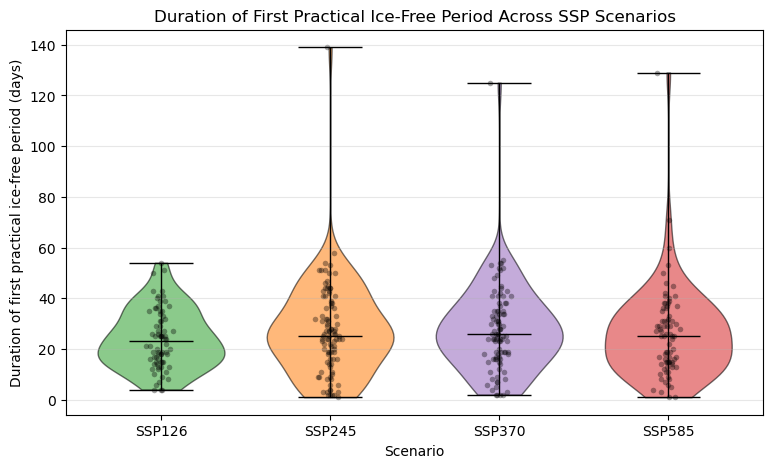

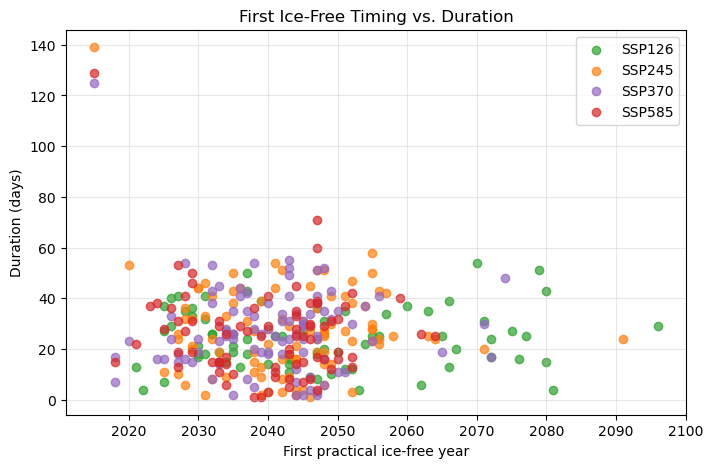

In [7]:
#### PLOTTING #####

duration_data = [
    events_only.loc[
        events_only["scenario"] == scenario,
        "practical_ice_free_duration_days",
    ].dropna().values
    for scenario in SCENARIO_ORDER
]

fig, ax = plt.subplots(figsize=(9, 5))
violins = ax.violinplot(
    duration_data,
    positions=np.arange(len(SCENARIO_ORDER)),
    showmeans=False,
    showmedians=True,
    widths=0.75,
)

for body, scenario in zip(violins["bodies"], SCENARIO_ORDER):
    body.set_facecolor(SCENARIO_COLORS[scenario])
    body.set_edgecolor("black")
    body.set_alpha(0.55)

for key in ["cbars", "cmins", "cmaxes", "cmedians"]:
    violins[key].set_color("black")
    violins[key].set_linewidth(1)

for position, values in enumerate(duration_data):
    jitter = np.random.default_rng(7).normal(0, 0.035, size=len(values))
    ax.scatter(
        np.full(len(values), position) + jitter,
        values,
        s=16,
        color="black",
        alpha=0.35,
        linewidths=0,
    )

ax.set_xticks(np.arange(len(SCENARIO_ORDER)))
ax.set_xticklabels(SCENARIO_ORDER)
ax.set_title("Duration of First Practical Ice-Free Period Across SSP Scenarios")
ax.set_xlabel("Scenario")
ax.set_ylabel("Duration of first practical ice-free period (days)")
ax.grid(axis="y", alpha=0.3)
fig.savefig(FIGURE_DIR / "first_ice_free_duration_by_ssp.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for scenario in SCENARIO_ORDER:
    plot_data = ice_free_results.loc[ice_free_results["scenario"] == scenario]
    ax.scatter(
        plot_data["first_practical_year"],
        plot_data["practical_ice_free_duration_days"],
        alpha=0.7,
        color=SCENARIO_COLORS[scenario],
        label=scenario,
    )

ax.set_title("First Ice-Free Timing vs. Duration")
ax.set_xlabel("First practical ice-free year")
ax.set_ylabel("Duration (days)")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(FIGURE_DIR / "first_ice_free_timing_vs_duration.png", dpi=300, bbox_inches="tight")
plt.show()
